In [ ]:
#Task 1: Understand the Business Problem
What is the business about?
What problem is the business trying to solve?
What decision can machine learning help the business make?
What is the target variable in the dataset?
What are the input features?
Why is this prediction useful for the business?
# Explanation: Stylehub is a fashion business that sells clothing and accessories across
   multiple products, including activewear, footwear, outerwear, etc. 
   The business manages inventory across different seasons, supplier regions and promotional campaigns.
   Stylehub struggles with stockout situations where a product runs out of inventory
    before it can be restocked. Machine learning can help StyleHub predict which SKUs are
    likely to face a stockout in the near future. The target for the given dataset is stockout_Risk.
    The input features are product category, season supplies, region, promotional
    type, discount, current inventory, website views, and inventory turnover and gross
    margin percent. This prediction will be useful for the business because it is an accurate stockout prediction
    that allows StyleHub to act before a product's stock runs out and place a restock order before time.
    This analysis protects the revenue and improves customer satisfaction.     
        

In [1]:
import pandas as pd

from IPython.display import display

file_path = r"C:\Users\luqma\Downloads\stylehub_inventory_stockout_dataset.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")

print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (345, 20)


C:\Users\luqma\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():
C:\Users\luqma\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Conditional Formatting extension is not supported and will be removed
  for idx, row in parser.parse():


,SKU_ID,Week_Start_Date,Product_Category,Season,Supplier_Region,Promotion_Type,Unit_Price,Discount_Percent,Units_Sold_Last_30_Days,Current_Inventory,Supplier_Lead_Time_Days,Days_Since_Last_Restock,Website_Views_Last_30_Days,Online_Search_Trend,Customer_Rating,Return_Rate_Percent,Competitor_Price_Index,Inventory_Turnover,Gross_Margin_Percent,Stockout_Risk
0,SH-AC-0001,2026-01-30,Accessories,All Season,Asia,Homepage Feature,29.13,25,28,87,21,6,817,Medium,4.8,12.2,1.00,0.32,17.2,No
1,SH-AC-0002,2026-03-13,Activewear,Fall,Canada,NaN,115.09,0,41,92,3,26,821,Medium,4.1,13.3,1.16,0.45,45.4,No
2,SH-OU-0003,2026-02-26,Outerwear,Spring,Canada,Clearance,171.27,15,94,40,7,31,1274,Medium,3.4,10.9,1.17,2.35,41.0,Yes
3,SH-WO-0004,2026-02-15,Women Apparel,Winter,United States,Email Promo,90.97,15,51,37,2,18,666,Medium,3.9,8.8,0.94,1.38,53.0,Yes
4,SH-FO-0005,2026-02-09,Footwear,Fall,United States,NaN,114.88,0,51,52,6,25,1779,Low,3.6,10.3,1.05,0.98,53.2,No


In [2]:
print("Dataset Shape")

# Print a separator line to make the output clear
print("-" * 50)

# Show the number of rows and columns in the dataset
print(df.shape)

Dataset Shape
--------------------------------------------------
(345, 20)


In [3]:
# Print a title for this output
print("First Five Rows of the Dataset")

# Print a separator line to make the output clear
print("-" * 50)

# Display the first five rows of the dataset
display(df.head())

First Five Rows of the Dataset
--------------------------------------------------


,SKU_ID,Week_Start_Date,Product_Category,Season,Supplier_Region,Promotion_Type,Unit_Price,Discount_Percent,Units_Sold_Last_30_Days,Current_Inventory,Supplier_Lead_Time_Days,Days_Since_Last_Restock,Website_Views_Last_30_Days,Online_Search_Trend,Customer_Rating,Return_Rate_Percent,Competitor_Price_Index,Inventory_Turnover,Gross_Margin_Percent,Stockout_Risk
0,SH-AC-0001,2026-01-30,Accessories,All Season,Asia,Homepage Feature,29.13,25,28,87,21,6,817,Medium,4.8,12.2,1.00,0.32,17.2,No
1,SH-AC-0002,2026-03-13,Activewear,Fall,Canada,NaN,115.09,0,41,92,3,26,821,Medium,4.1,13.3,1.16,0.45,45.4,No
2,SH-OU-0003,2026-02-26,Outerwear,Spring,Canada,Clearance,171.27,15,94,40,7,31,1274,Medium,3.4,10.9,1.17,2.35,41.0,Yes
3,SH-WO-0004,2026-02-15,Women Apparel,Winter,United States,Email Promo,90.97,15,51,37,2,18,666,Medium,3.9,8.8,0.94,1.38,53.0,Yes
4,SH-FO-0005,2026-02-09,Footwear,Fall,United States,NaN,114.88,0,51,52,6,25,1779,Low,3.6,10.3,1.05,0.98,53.2,No


In [4]:
print("Last Five Rows of the Dataset")

# Print a separator line to make the output clear
print("-" * 50)

# Display the last five rows of the dataset
display(df.tail())

Last Five Rows of the Dataset
--------------------------------------------------


,SKU_ID,Week_Start_Date,Product_Category,Season,Supplier_Region,Promotion_Type,Unit_Price,Discount_Percent,Units_Sold_Last_30_Days,Current_Inventory,Supplier_Lead_Time_Days,Days_Since_Last_Restock,Website_Views_Last_30_Days,Online_Search_Trend,Customer_Rating,Return_Rate_Percent,Competitor_Price_Index,Inventory_Turnover,Gross_Margin_Percent,Stockout_Risk
340,SH-AC-0175,2026-04-09,Activewear,Summer,Canada,NaN,62.12,0,45,77,6,18,832,Medium,4.7,9.8,0.91,0.58,39.8,No
341,SH-AC-0239,2026-04-07,Accessories,Winter,Canada,NaN,47.37,0,49,52,2,15,1059,High,4.0,7.3,0.88,0.94,38.2,No
342,SH-AC-0185,2026-01-28,Accessories,All Season,United States,Clearance,40.54,20,81,25,2,29,1417,High,4.2,7.8,0.97,3.24,50.6,Yes
343,SH-AC-0063,2026-01-01,Accessories,Summer,Europe,Homepage Feature,77.06,5,48,78,11,13,1680,Low,4.6,10.5,0.89,0.62,32.6,No
344,SH-AC-0307,2026-04-02,Activewear,Fall,United States,Social Media Promo,71.96,30,58,53,5,5,1251,Medium,4.3,11.3,1.01,1.09,47.8,No


In [5]:
# Print a title for this output
print("Column Names")

# Print a separator line to make the output clear
print("-" * 50)

# Display all column names as a list
print(df.columns.tolist())

Column Names
--------------------------------------------------
['SKU_ID', 'Week_Start_Date', 'Product_Category', 'Season', 'Supplier_Region', 'Promotion_Type', 'Unit_Price', 'Discount_Percent', 'Units_Sold_Last_30_Days', 'Current_Inventory', 'Supplier_Lead_Time_Days', 'Days_Since_Last_Restock', 'Website_Views_Last_30_Days', 'Online_Search_Trend', 'Customer_Rating', 'Return_Rate_Percent', 'Competitor_Price_Index', 'Inventory_Turnover', 'Gross_Margin_Percent', 'Stockout_Risk']


In [6]:
print("Dataset Information")

# Print a separator line to make the output clear
print("-" * 50)

# Show column names, non-null values, and data types
df.info()

Dataset Information
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345 entries, 0 to 344
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   SKU_ID                      345 non-null    object        
 1   Week_Start_Date             345 non-null    datetime64[ns]
 2   Product_Category            345 non-null    object        
 3   Season                      345 non-null    object        
 4   Supplier_Region             345 non-null    object        
 5   Promotion_Type              184 non-null    object        
 6   Unit_Price                  345 non-null    float64       
 7   Discount_Percent            345 non-null    int64         
 8   Units_Sold_Last_30_Days     345 non-null    int64         
 9   Current_Inventory           345 non-null    int64         
 10  Supplier_Lead_Time_Days     345 non-null    int64  

In [7]:
# Print a title for this output
print("Data Types of Each Column")

# Print a separator line to make the output clear
print("-" * 50)

# Display the data type of each column
display(df.dtypes)

Data Types of Each Column
--------------------------------------------------


SKU_ID                                object
Week_Start_Date               datetime64[ns]
Product_Category                      object
Season                                object
Supplier_Region                       object
Promotion_Type                        object
Unit_Price                           float64
Discount_Percent                       int64
Units_Sold_Last_30_Days                int64
Current_Inventory                      int64
Supplier_Lead_Time_Days                int64
Days_Since_Last_Restock                int64
Website_Views_Last_30_Days             int64
Online_Search_Trend                   object
Customer_Rating                      float64
Return_Rate_Percent                  float64
Competitor_Price_Index               float64
Inventory_Turnover                   float64
Gross_Margin_Percent                 float64
Stockout_Risk                         object
dtype: object

In [8]:
print("Missing Values in Each Column")

# Print a separator line to make the output clear
print("-" * 50)

# Count missing values in each column
missing_values = df.isnull().sum()

# Display the number of missing values for each column
display(missing_values)

Missing Values in Each Column
--------------------------------------------------


SKU_ID                          0
Week_Start_Date                 0
Product_Category                0
Season                          0
Supplier_Region                 0
Promotion_Type                161
Unit_Price                      0
Discount_Percent                0
Units_Sold_Last_30_Days         0
Current_Inventory               0
Supplier_Lead_Time_Days         0
Days_Since_Last_Restock         0
Website_Views_Last_30_Days      0
Online_Search_Trend             0
Customer_Rating                12
Return_Rate_Percent             8
Competitor_Price_Index          0
Inventory_Turnover              0
Gross_Margin_Percent            0
Stockout_Risk                   0
dtype: int64

In [9]:
print("Number of Duplicate Rows")

# Print a separator line to make the output clear
print("-" * 50)

# Count the number of duplicate rows in the dataset
duplicate_rows = df.duplicated().sum()

# Display the number of duplicate rows
print(duplicate_rows)

Number of Duplicate Rows
--------------------------------------------------
5


In [10]:
# Print a title for this output
print("Summary Statistics for Numerical Columns")

# Print a separator line to make the output clear
print("-" * 50)

# Display summary statistics for numerical columns
display(df.describe())

Summary Statistics for Numerical Columns
--------------------------------------------------


,Week_Start_Date,Unit_Price,Discount_Percent,Units_Sold_Last_30_Days,Current_Inventory,Supplier_Lead_Time_Days,Days_Since_Last_Restock,Website_Views_Last_30_Days,Customer_Rating,Return_Rate_Percent,Competitor_Price_Index,Inventory_Turnover,Gross_Margin_Percent
count,345,345.000000,345.000000,345.000000,345.000000,345.000000,345.000000,345.000000,333.000000,337.000000,345.000000,345.000000,345.000000
mean,2026-03-09 01:27:39.130434816,98.066435,9.492754,62.756522,59.289855,9.947826,20.307246,1089.110145,4.069369,11.511869,1.017188,7.899130,37.774783
min,2026-01-01 00:00:00,15.010000,0.000000,13.000000,0.000000,2.000000,1.000000,80.000000,2.500000,1.000000,0.860000,0.120000,14.600000
25%,2026-01-30 00:00:00,59.670000,0.000000,46.000000,31.000000,4.000000,12.000000,805.000000,3.800000,8.900000,0.940000,0.580000,29.000000
50%,2026-03-10 00:00:00,92.560000,5.000000,59.000000,58.000000,7.000000,21.000000,1080.000000,4.100000,11.300000,1.010000,1.090000,37.900000
75%,2026-04-12 00:00:00,122.230000,20.000000,79.000000,85.000000,16.000000,29.000000,1363.000000,4.400000,14.000000,1.100000,2.260000,46.700000
max,2026-05-20 00:00:00,255.930000,30.000000,145.000000,174.000000,28.000000,52.000000,2237.000000,5.000000,21.600000,1.180000,130.000000,57.900000
std,NaN,47.275238,10.955278,24.519069,36.818024,7.152220,11.238875,404.628669,0.442636,3.847615,0.092463,22.057735,10.777435


In [11]:
# Store the target column name in a variable
target_column = "Stockout_Risk"

# Print the target variable name
print("Target variable:")

# Display the target column name
print(target_column)

Target variable:
Stockout_Risk


In [12]:
print("Target variable values:")

# Print a separator line
print("-" * 50)

# Display the unique values in the target column
print(df[target_column].unique())

Target variable values:
--------------------------------------------------
['No' 'Yes']


In [13]:
# Print a title for the target class distribution
print("Target class distribution:")

# Print a separator line
print("-" * 50)

# Count how many customers are in each target class
target_counts = df[target_column].value_counts()

# Display the target class counts
display(target_counts)

Target class distribution:
--------------------------------------------------


Stockout_Risk
No     181
Yes    164
Name: count, dtype: int64

In [14]:
feature_columns = df.drop(columns=[target_column]).columns.tolist()

# Print a title for the feature columns
print("Feature columns:")

# Print a separator line
print("-" * 50)

# Display the feature columns
print(feature_columns)

Feature columns:
--------------------------------------------------
['SKU_ID', 'Week_Start_Date', 'Product_Category', 'Season', 'Supplier_Region', 'Promotion_Type', 'Unit_Price', 'Discount_Percent', 'Units_Sold_Last_30_Days', 'Current_Inventory', 'Supplier_Lead_Time_Days', 'Days_Since_Last_Restock', 'Website_Views_Last_30_Days', 'Online_Search_Trend', 'Customer_Rating', 'Return_Rate_Percent', 'Competitor_Price_Index', 'Inventory_Turnover', 'Gross_Margin_Percent']


In [15]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Select categorical columns from the dataset
categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()

# Remove the target column from categorical columns because it is not an input feature
categorical_columns.remove(target_column)

# Print a title for numerical columns
print("Numerical feature columns:")

# Display numerical columns
print(numerical_columns)

# Print a separator line
print("-" * 50)

# Print a title for categorical columns
print("Categorical feature columns:")

# Display categorical columns
print(categorical_columns)

Numerical feature columns:
['Unit_Price', 'Discount_Percent', 'Units_Sold_Last_30_Days', 'Current_Inventory', 'Supplier_Lead_Time_Days', 'Days_Since_Last_Restock', 'Website_Views_Last_30_Days', 'Customer_Rating', 'Return_Rate_Percent', 'Competitor_Price_Index', 'Inventory_Turnover', 'Gross_Margin_Percent']
--------------------------------------------------
Categorical feature columns:
['SKU_ID', 'Product_Category', 'Season', 'Supplier_Region', 'Promotion_Type', 'Online_Search_Trend']


In [16]:
# Create a copy of the original dataset
df_clean = df.copy()

# Print a message to confirm that the copy was created
print("A copy of the dataset has been created.")

# Show the shape of the original dataset
print("Original dataset shape:", df.shape)

# Show the shape of the copied dataset
print("Copied dataset shape:", df_clean.shape)

A copy of the dataset has been created.
Original dataset shape: (345, 20)
Copied dataset shape: (345, 20)


In [17]:
# Count the number of duplicate rows before cleaning
duplicates_before = df_clean.duplicated().sum()

# Print the number of duplicate rows before cleaning
print("Number of duplicate rows before cleaning:", duplicates_before)

Number of duplicate rows before cleaning: 5


In [18]:
# Remove duplicate rows from the dataset
df_clean = df_clean.drop_duplicates()

# Print a message to confirm that duplicate rows were removed
print("Duplicate rows have been removed.")

Duplicate rows have been removed.


In [19]:
# Show the shape of the dataset after removing duplicate rows
print("Dataset shape after removing duplicates:", df_clean.shape)

# Count the number of duplicate rows after cleaning
duplicates_after = df_clean.duplicated().sum()

# Print the number of duplicate rows after cleaning
print("Number of duplicate rows after cleaning:", duplicates_after)

Dataset shape after removing duplicates: (340, 20)
Number of duplicate rows after cleaning: 0


In [20]:
print("Missing Values Before Handling")

# Print a separator line to make the output clear
print("-" * 50)

# Count missing values in each column before handling them
missing_values_before = df_clean.isnull().sum()

# Display missing values before handling
display(missing_values_before)

Missing Values Before Handling
--------------------------------------------------


SKU_ID                          0
Week_Start_Date                 0
Product_Category                0
Season                          0
Supplier_Region                 0
Promotion_Type                159
Unit_Price                      0
Discount_Percent                0
Units_Sold_Last_30_Days         0
Current_Inventory               0
Supplier_Lead_Time_Days         0
Days_Since_Last_Restock         0
Website_Views_Last_30_Days      0
Online_Search_Trend             0
Customer_Rating                12
Return_Rate_Percent             8
Competitor_Price_Index          0
Inventory_Turnover              0
Gross_Margin_Percent            0
Stockout_Risk                   0
dtype: int64

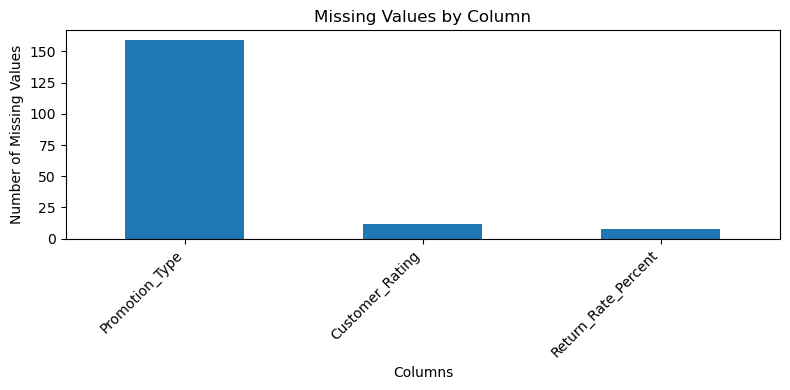

In [21]:
# Import matplotlib for creating charts
import matplotlib.pyplot as plt

# Select only columns that have missing values
missing_columns = missing_values_before[missing_values_before > 0]

# Create a figure for the missing values chart
plt.figure(figsize=(8, 4))

# Create a bar chart for columns with missing values
missing_columns.plot(kind="bar")

# Add a title to the chart
plt.title("Missing Values by Column")

# Add a label to the x-axis
plt.xlabel("Columns")

# Add a label to the y-axis
plt.ylabel("Number of Missing Values")

# Rotate x-axis labels to make them easier to read
plt.xticks(rotation=45, ha="right")

# Adjust the layout so labels do not overlap
plt.tight_layout()

# Display the chart
plt.show()

In [22]:
# Select numerical columns from the cleaned dataset
numerical_columns = df_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Select categorical columns from the cleaned dataset
categorical_columns = df_clean.select_dtypes(include=["object"]).columns.tolist()

# Print numerical columns
print("Numerical columns:")

# Display numerical columns
print(numerical_columns)

# Print a separator line
print("-" * 50)

# Print categorical columns
print("Categorical columns:")

# Display categorical columns
print(categorical_columns)

Numerical columns:
['Unit_Price', 'Discount_Percent', 'Units_Sold_Last_30_Days', 'Current_Inventory', 'Supplier_Lead_Time_Days', 'Days_Since_Last_Restock', 'Website_Views_Last_30_Days', 'Customer_Rating', 'Return_Rate_Percent', 'Competitor_Price_Index', 'Inventory_Turnover', 'Gross_Margin_Percent']
--------------------------------------------------
Categorical columns:
['SKU_ID', 'Product_Category', 'Season', 'Supplier_Region', 'Promotion_Type', 'Online_Search_Trend', 'Stockout_Risk']


In [23]:
# Loop through each numerical column
for column in numerical_columns:
    
    # Calculate the median value of the current numerical column
    median_value = df_clean[column].median()
    
    # Fill missing values in the current column with the median value
    df_clean[column] = df_clean[column].fillna(median_value)

# Print a message after handling numerical missing values
print("Missing values in numerical columns have been filled with the median.")

Missing values in numerical columns have been filled with the median.


In [24]:
for column in categorical_columns:
    
    # Calculate the most frequent value of the current categorical column
    mode_value = df_clean[column].mode()[0]
    
    # Fill missing values in the current column with the most frequent value
    df_clean[column] = df_clean[column].fillna(mode_value)

# Print a message after handling categorical missing values
print("Missing values in categorical columns have been filled with the mode.")

Missing values in categorical columns have been filled with the mode.


In [25]:
print("Missing Values After Handling")

# Print a separator line to make the output clear
print("-" * 50)

# Count missing values after handling them
missing_values_after = df_clean.isnull().sum()

# Display missing values after handling
display(missing_values_after)

Missing Values After Handling
--------------------------------------------------


SKU_ID                        0
Week_Start_Date               0
Product_Category              0
Season                        0
Supplier_Region               0
Promotion_Type                0
Unit_Price                    0
Discount_Percent              0
Units_Sold_Last_30_Days       0
Current_Inventory             0
Supplier_Lead_Time_Days       0
Days_Since_Last_Restock       0
Website_Views_Last_30_Days    0
Online_Search_Trend           0
Customer_Rating               0
Return_Rate_Percent           0
Competitor_Price_Index        0
Inventory_Turnover            0
Gross_Margin_Percent          0
Stockout_Risk                 0
dtype: int64

In [26]:
print("Dataset shape after handling missing values:", df_clean.shape)

# Display the first five rows of the cleaned dataset
display(df_clean.head())

Dataset shape after handling missing values: (340, 20)


,SKU_ID,Week_Start_Date,Product_Category,Season,Supplier_Region,Promotion_Type,Unit_Price,Discount_Percent,Units_Sold_Last_30_Days,Current_Inventory,Supplier_Lead_Time_Days,Days_Since_Last_Restock,Website_Views_Last_30_Days,Online_Search_Trend,Customer_Rating,Return_Rate_Percent,Competitor_Price_Index,Inventory_Turnover,Gross_Margin_Percent,Stockout_Risk
0,SH-AC-0001,2026-01-30,Accessories,All Season,Asia,Homepage Feature,29.13,25,28,87,21,6,817,Medium,4.8,12.2,1.00,0.32,17.2,No
1,SH-AC-0002,2026-03-13,Activewear,Fall,Canada,Social Media Promo,115.09,0,41,92,3,26,821,Medium,4.1,13.3,1.16,0.45,45.4,No
2,SH-OU-0003,2026-02-26,Outerwear,Spring,Canada,Clearance,171.27,15,94,40,7,31,1274,Medium,3.4,10.9,1.17,2.35,41.0,Yes
3,SH-WO-0004,2026-02-15,Women Apparel,Winter,United States,Email Promo,90.97,15,51,37,2,18,666,Medium,3.9,8.8,0.94,1.38,53.0,Yes
4,SH-FO-0005,2026-02-09,Footwear,Fall,United States,Social Media Promo,114.88,0,51,52,6,25,1779,Low,3.6,10.3,1.05,0.98,53.2,No


In [27]:
target_column = "stouckout_Risk"

# Print the target column name
print("Target column:")

# Display the target column
print(target_column)

Target column:
stouckout_Risk


In [28]:
# Select numerical columns from the cleaned dataset
numerical_features = df_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Print a title for numerical features
print("Numerical feature columns:")

# Print a separator line
print("-" * 50)

# Display numerical feature columns
print(numerical_features)

Numerical feature columns:
--------------------------------------------------
['Unit_Price', 'Discount_Percent', 'Units_Sold_Last_30_Days', 'Current_Inventory', 'Supplier_Lead_Time_Days', 'Days_Since_Last_Restock', 'Website_Views_Last_30_Days', 'Customer_Rating', 'Return_Rate_Percent', 'Competitor_Price_Index', 'Inventory_Turnover', 'Gross_Margin_Percent']


In [30]:
categorical_features = [
    col
    for col in df_clean.select_dtypes(include=["object"]).columns
    if col != target_column
]

# Display the categorical feature names
print("Categorical Feature Columns")
print("-" * 50)
print(categorical_features)

Categorical Feature Columns
--------------------------------------------------
['SKU_ID', 'Product_Category', 'Season', 'Supplier_Region', 'Promotion_Type', 'Online_Search_Trend', 'Stockout_Risk']


In [31]:
# Count the number of numerical features
num_count = len(numerical_features)

# Count the number of categorical features
cat_count = len(categorical_features)

# Print the number of numerical features
print("Number of numerical features:", num_count)

# Print the number of categorical features
print("Number of categorical features:", cat_count)

Number of numerical features: 12
Number of categorical features: 7


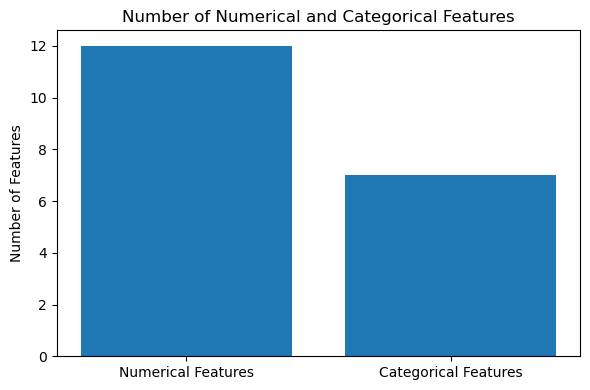

In [32]:
# Import matplotlib for creating charts
import matplotlib.pyplot as plt

# Create labels for the chart
feature_type_labels = ["Numerical Features", "Categorical Features"]

# Create values for the chart
feature_type_counts = [num_count, cat_count]

# Create a figure for the chart
plt.figure(figsize=(6, 4))

# Create a bar chart
plt.bar(feature_type_labels, feature_type_counts)

# Add a chart title
plt.title("Number of Numerical and Categorical Features")

# Add a label to the y-axis
plt.ylabel("Number of Features")

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

In [33]:
# Print a title for unique values
print("Unique values in categorical features")

# Print a separator line
print("-" * 50)

# Loop through each categorical feature
for column in categorical_features:
    
    # Print the column name
    print("Column:", column)
    
    # Print the unique values in the column
    print(df_clean[column].unique())
    
    # Print a separator line
    print("-" * 50)

Unique values in categorical features
--------------------------------------------------
Column: SKU_ID
['SH-AC-0001' 'SH-AC-0002' 'SH-OU-0003' 'SH-WO-0004' 'SH-FO-0005'
 'SH-AC-0006' 'SH-ME-0007' 'SH-OU-0008' 'SH-WO-0009' 'SH-WO-0010'
 'SH-AC-0011' 'SH-AC-0012' 'SH-OU-0013' 'SH-FO-0014' 'SH-WO-0015'
 'SH-OU-0016' 'SH-WO-0017' 'SH-AC-0018' 'SH-AC-0019' 'SH-AC-0020'
 'SH-ME-0021' 'SH-AC-0022' 'SH-FO-0023' 'SH-WO-0024' 'SH-WO-0025'
 'SH-FO-0026' 'SH-AC-0027' 'SH-ME-0028' 'SH-WO-0029' 'SH-FO-0030'
 'SH-FO-0031' 'SH-AC-0032' 'SH-AC-0033' 'SH-ME-0034' 'SH-FO-0035'
 'SH-WO-0036' 'SH-ME-0037' 'SH-AC-0038' 'SH-AC-0039' 'SH-OU-0040'
 'SH-AC-0041' 'SH-OU-0042' 'SH-AC-0043' 'SH-WO-0044' 'SH-WO-0045'
 'SH-AC-0046' 'SH-FO-0047' 'SH-FO-0048' 'SH-FO-0049' 'SH-AC-0050'
 'SH-WO-0051' 'SH-AC-0052' 'SH-AC-0053' 'SH-WO-0054' 'SH-WO-0055'
 'SH-OU-0056' 'SH-WO-0057' 'SH-AC-0058' 'SH-AC-0059' 'SH-AC-0060'
 'SH-FO-0061' 'SH-AC-0062' 'SH-AC-0063' 'SH-AC-0064' 'SH-OU-0065'
 'SH-AC-0066' 'SH-FO-0067' 'SH-AC-0068

In [34]:
# Count unique values for each categorical feature
categorical_unique_counts = df_clean[categorical_features].nunique()

# Print a title
print("Number of unique values in each categorical feature:")

# Print a separator line
print("-" * 50)

# Display the number of unique values
display(categorical_unique_counts)

Number of unique values in each categorical feature:
--------------------------------------------------


SKU_ID                 340
Product_Category         6
Season                   5
Supplier_Region          4
Promotion_Type           4
Online_Search_Trend      3
Stockout_Risk            2
dtype: int64

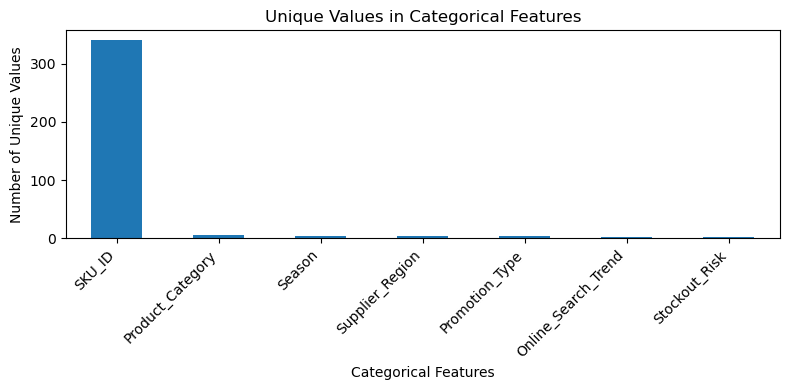

In [35]:
# Create a figure for the categorical unique values chart
plt.figure(figsize=(8, 4))

# Create a bar chart for unique values in categorical columns
categorical_unique_counts.plot(kind="bar")

# Add a chart title
plt.title("Unique Values in Categorical Features")

# Add a label to the x-axis
plt.xlabel("Categorical Features")

# Add a label to the y-axis
plt.ylabel("Number of Unique Values")

# Rotate x-axis labels
plt.xticks(rotation=45, ha="right")

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

In [38]:
target_column = "Stockout_Risk"

# Print the target column name
print("Target column:")

# Display the target column
print(target_column)

Target column:
Stockout_Risk


In [39]:
# Create X by removing the target column from the dataset
X = df_clean.drop(columns=[target_column])

# Create y by selecting only the target column
y = df_clean[target_column]

# Print a message to confirm that X and y have been created
print("X and y have been defined successfully.")

X and y have been defined successfully.


In [40]:
# Print the shape of X
print("Shape of X:")

# Display the number of rows and columns in X
print(X.shape)

# Print a separator line
print("-" * 50)

# Print the shape of y
print("Shape of y:")

# Display the number of rows in y
print(y.shape)

Shape of X:
(340, 19)
--------------------------------------------------
Shape of y:
(340,)


In [41]:
print("First five rows of X:")

# Print a separator line
print("-" * 50)

# Display the first five rows of X
display(X.head())

First five rows of X:
--------------------------------------------------


,SKU_ID,Week_Start_Date,Product_Category,Season,Supplier_Region,Promotion_Type,Unit_Price,Discount_Percent,Units_Sold_Last_30_Days,Current_Inventory,Supplier_Lead_Time_Days,Days_Since_Last_Restock,Website_Views_Last_30_Days,Online_Search_Trend,Customer_Rating,Return_Rate_Percent,Competitor_Price_Index,Inventory_Turnover,Gross_Margin_Percent
0,SH-AC-0001,2026-01-30,Accessories,All Season,Asia,Homepage Feature,29.13,25,28,87,21,6,817,Medium,4.8,12.2,1.00,0.32,17.2
1,SH-AC-0002,2026-03-13,Activewear,Fall,Canada,Social Media Promo,115.09,0,41,92,3,26,821,Medium,4.1,13.3,1.16,0.45,45.4
2,SH-OU-0003,2026-02-26,Outerwear,Spring,Canada,Clearance,171.27,15,94,40,7,31,1274,Medium,3.4,10.9,1.17,2.35,41.0
3,SH-WO-0004,2026-02-15,Women Apparel,Winter,United States,Email Promo,90.97,15,51,37,2,18,666,Medium,3.9,8.8,0.94,1.38,53.0
4,SH-FO-0005,2026-02-09,Footwear,Fall,United States,Social Media Promo,114.88,0,51,52,6,25,1779,Low,3.6,10.3,1.05,0.98,53.2


In [42]:
# Print a title for y
print("First five values of y:")

# Print a separator line
print("-" * 50)

# Display the first five values of y
display(y.head())

First five values of y:
--------------------------------------------------


0     No
1     No
2    Yes
3    Yes
4     No
Name: Stockout_Risk, dtype: object

In [43]:
target_distribution = y.value_counts()

# Print a title for the target distribution
print("Target class distribution:")

# Print a separator line
print("-" * 50)

# Display the target class distribution
display(target_distribution)

Target class distribution:
--------------------------------------------------


Stockout_Risk
No     177
Yes    163
Name: count, dtype: int64

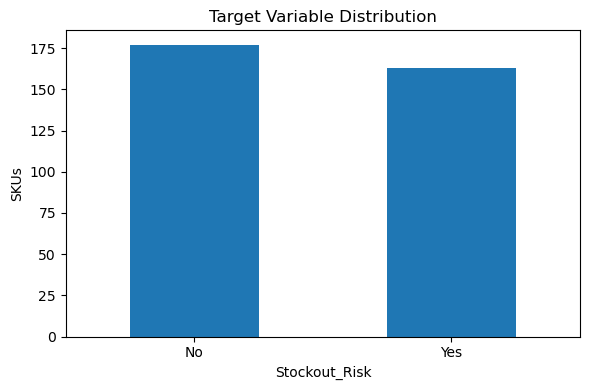

In [46]:
# Import matplotlib for creating charts
import matplotlib.pyplot as plt

# Create a figure for the target distribution chart
plt.figure(figsize=(6, 4))

# Create a bar chart for the target variable
target_distribution.plot(kind="bar")

# Add a title to the chart
plt.title("Target Variable Distribution")

# Add a label to the x-axis
plt.xlabel("Stockout_Risk")

# Add a label to the y-axis
plt.ylabel("SKUs")

# Rotate x-axis labels to make them easier to read
plt.xticks(rotation=0)

# Adjust layout to avoid overlap
plt.tight_layout()

# Display the chart
plt.show()

In [47]:
# Import train_test_split function from scikit-learn
from sklearn.model_selection import train_test_split

In [48]:
# Split X and y into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    
    # Use X as the input features
    X,
    
    # Use y as the target variable
    y,
    
    # Use 20% of the data for testing
    test_size=0.2,
    
    # Keep the same target class distribution in train and test sets
    stratify=y,
    
    # Use a fixed random state to make the result reproducible
    random_state=42
)

# Print a message to confirm that the data has been split
print("Data has been split into training and testing sets.")

Data has been split into training and testing sets.


In [49]:
# Print the shape of X_train
print("X_train shape:")

# Display the number of rows and columns in X_train
print(X_train.shape)

# Print a separator line
print("-" * 50)

# Print the shape of X_test
print("X_test shape:")

# Display the number of rows and columns in X_test
print(X_test.shape)

# Print a separator line
print("-" * 50)

# Print the shape of y_train
print("y_train shape:")

# Display the number of target values in y_train
print(y_train.shape)

# Print a separator line
print("-" * 50)

# Print the shape of y_test
print("y_test shape:")

# Display the number of target values in y_test
print(y_test.shape)

X_train shape:
(272, 19)
--------------------------------------------------
X_test shape:
(68, 19)
--------------------------------------------------
y_train shape:
(272,)
--------------------------------------------------
y_test shape:
(68,)


In [50]:
print("Target distribution in training set:")

# Print a separator line
print("-" * 50)

# Count the number of Yes and No values in y_train
train_distribution = y_train.value_counts()

# Display the target distribution in the training set
display(train_distribution)

Target distribution in training set:
--------------------------------------------------


Stockout_Risk
No     142
Yes    130
Name: count, dtype: int64

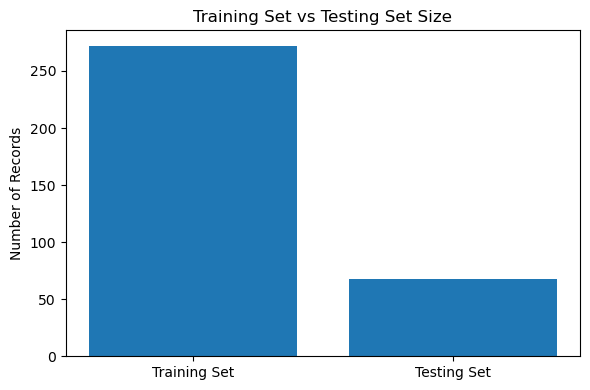

In [51]:
# Import matplotlib for creating charts
import matplotlib.pyplot as plt

# Create labels for the chart
split_labels = ["Training Set", "Testing Set"]

# Create values for the chart
split_sizes = [len(X_train), len(X_test)]

# Create a figure for the chart
plt.figure(figsize=(6, 4))

# Create a bar chart for train and test size
plt.bar(split_labels, split_sizes)

# Add a title to the chart
plt.title("Training Set vs Testing Set Size")

# Add a label to the y-axis
plt.ylabel("Number of Records")

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

In [52]:
from sklearn.compose import ColumnTransformer

# Import OneHotEncoder to convert categorical variables into numerical columns
from sklearn.preprocessing import OneHotEncoder

In [53]:
# Select numerical feature columns from X
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Select categorical feature columns from X
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

# Print numerical features
print("Numerical features:")
print(numerical_features)

# Print a separator line
print("-" * 50)

# Print categorical features
print("Categorical features:")
print(categorical_features)

Numerical features:
['Unit_Price', 'Discount_Percent', 'Units_Sold_Last_30_Days', 'Current_Inventory', 'Supplier_Lead_Time_Days', 'Days_Since_Last_Restock', 'Website_Views_Last_30_Days', 'Customer_Rating', 'Return_Rate_Percent', 'Competitor_Price_Index', 'Inventory_Turnover', 'Gross_Margin_Percent']
--------------------------------------------------
Categorical features:
['SKU_ID', 'Product_Category', 'Season', 'Supplier_Region', 'Promotion_Type', 'Online_Search_Trend']


In [54]:
# Create a one-hot encoder for categorical variables
# handle_unknown="ignore" prevents errors if new categories appear in the test set
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# Create a ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(
    
    # Define the transformations
    transformers=[
        
        # Apply one-hot encoding to categorical features
        ("categorical", encoder, categorical_features),
        
        # Keep numerical features unchanged
        ("numerical", "passthrough", numerical_features)
    ]
)

# Print a message to confirm that the preprocessor has been created
print("Preprocessor has been created successfully.")

Preprocessor has been created successfully.


In [55]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# Create a ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(
    
    # Define the transformations
    transformers=[
        
        # Apply one-hot encoding to categorical features
        ("categorical", encoder, categorical_features),
        
        # Keep numerical features unchanged
        ("numerical", "passthrough", numerical_features)
    ]
)

# Print a message to confirm that the preprocessor has been created
print("Preprocessor has been created successfully.")

Preprocessor has been created successfully.


In [56]:
X_train_processed = preprocessor.fit_transform(X_train)

# Transform the testing data using the same fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

# Print a message to confirm preprocessing is complete
print("Training and testing data have been preprocessed successfully.")

Training and testing data have been preprocessed successfully.


In [57]:
print("Original X_train shape:")
print(X_train.shape)

# Print a separator line
print("-" * 50)

# Print the shape of the processed X_train
print("Processed X_train shape:")
print(X_train_processed.shape)

# Print a separator line
print("-" * 50)

# Print the shape of the original X_test
print("Original X_test shape:")
print(X_test.shape)

# Print a separator line
print("-" * 50)

# Print the shape of the processed X_test
print("Processed X_test shape:")
print(X_test_processed.shape)

Original X_train shape:
(272, 19)
--------------------------------------------------
Processed X_train shape:
(272, 306)
--------------------------------------------------
Original X_test shape:
(68, 19)
--------------------------------------------------
Processed X_test shape:
(68, 306)


In [58]:
encoded_categorical_features = preprocessor.named_transformers_["categorical"].get_feature_names_out(categorical_features)

# Combine encoded categorical feature names with numerical feature names
processed_feature_names = list(encoded_categorical_features) + numerical_features

# Print the total number of processed features
print("Number of processed features:", len(processed_feature_names))

# Print a separator line
print("-" * 50)

# Display the processed feature names
print(processed_feature_names)

Number of processed features: 306
--------------------------------------------------
['SKU_ID_SH-AC-0001', 'SKU_ID_SH-AC-0011', 'SKU_ID_SH-AC-0012', 'SKU_ID_SH-AC-0018', 'SKU_ID_SH-AC-0019', 'SKU_ID_SH-AC-0020', 'SKU_ID_SH-AC-0022', 'SKU_ID_SH-AC-0027', 'SKU_ID_SH-AC-0032', 'SKU_ID_SH-AC-0038', 'SKU_ID_SH-AC-0039', 'SKU_ID_SH-AC-0041', 'SKU_ID_SH-AC-0043', 'SKU_ID_SH-AC-0046', 'SKU_ID_SH-AC-0050', 'SKU_ID_SH-AC-0052', 'SKU_ID_SH-AC-0053', 'SKU_ID_SH-AC-0058', 'SKU_ID_SH-AC-0059', 'SKU_ID_SH-AC-0060', 'SKU_ID_SH-AC-0062', 'SKU_ID_SH-AC-0063', 'SKU_ID_SH-AC-0066', 'SKU_ID_SH-AC-0068', 'SKU_ID_SH-AC-0079', 'SKU_ID_SH-AC-0093', 'SKU_ID_SH-AC-0095', 'SKU_ID_SH-AC-0102', 'SKU_ID_SH-AC-0105', 'SKU_ID_SH-AC-0109', 'SKU_ID_SH-AC-0113', 'SKU_ID_SH-AC-0117', 'SKU_ID_SH-AC-0122', 'SKU_ID_SH-AC-0127', 'SKU_ID_SH-AC-0136', 'SKU_ID_SH-AC-0138', 'SKU_ID_SH-AC-0139', 'SKU_ID_SH-AC-0146', 'SKU_ID_SH-AC-0147', 'SKU_ID_SH-AC-0149', 'SKU_ID_SH-AC-0154', 'SKU_ID_SH-AC-0157', 'SKU_ID_SH-AC-0160', 'SKU_ID_SH-

In [59]:
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=processed_feature_names,
    index=X_train.index
)

# Convert processed testing data into a DataFrame
X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=processed_feature_names,
    index=X_test.index
)

# Display the first five rows of the processed training data
display(X_train_processed_df.head())

,SKU_ID_SH-AC-0001,SKU_ID_SH-AC-0011,SKU_ID_SH-AC-0012,SKU_ID_SH-AC-0018,SKU_ID_SH-AC-0019,SKU_ID_SH-AC-0020,SKU_ID_SH-AC-0022,SKU_ID_SH-AC-0027,SKU_ID_SH-AC-0032,SKU_ID_SH-AC-0038,...,Units_Sold_Last_30_Days,Current_Inventory,Supplier_Lead_Time_Days,Days_Since_Last_Restock,Website_Views_Last_30_Days,Customer_Rating,Return_Rate_Percent,Competitor_Price_Index,Inventory_Turnover,Gross_Margin_Percent
179,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,64.0,117.0,7.0,25.0,1247.0,4.1,7.6,1.16,0.55,51.8
26,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,77.0,49.0,5.0,7.0,1475.0,4.5,7.8,1.01,1.57,39.6
68,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,87.0,42.0,9.0,11.0,637.0,3.9,13.1,0.91,2.07,53.0
195,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,50.0,68.0,25.0,28.0,1440.0,4.4,7.2,0.86,0.74,55.6
234,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,46.0,111.0,7.0,22.0,1606.0,4.1,14.3,1.18,0.41,33.8


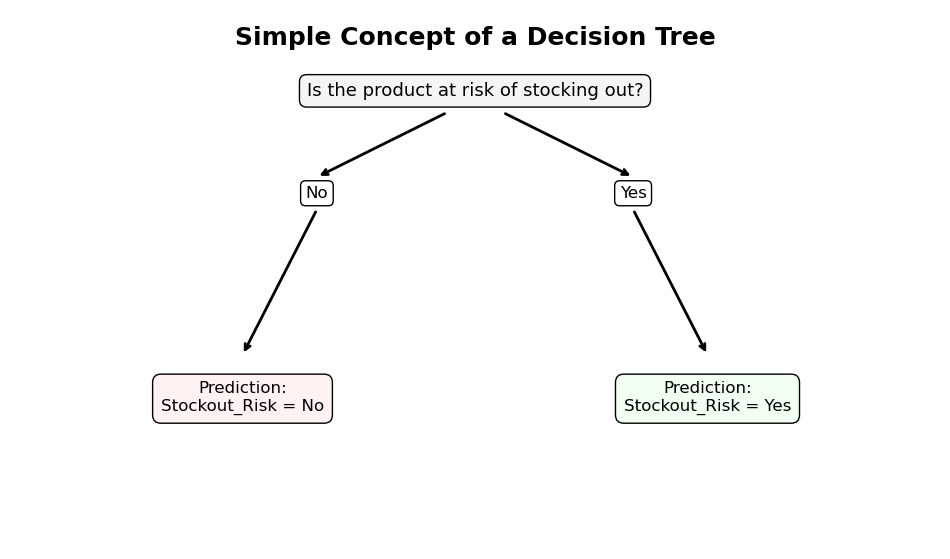

In [62]:

# Create a figure and axis with a larger size for a cleaner layout
fig, ax = plt.subplots(figsize=(12, 7))

# Set the x-axis limits
ax.set_xlim(0, 1)

# Set the y-axis limits
ax.set_ylim(0, 1)

# Turn off the axis because this is a conceptual diagram
ax.axis("off")

# Add the title of the figure at the top
ax.text(
    0.5, 0.97,
    "Simple Concept of a Decision Tree",
    ha="center",
    va="top",
    fontsize=18,
    fontweight="bold"
)

# Add the root node box
ax.text(
    0.5, 0.85,
    "Is the product at risk of stocking out?",
    ha="center",
    va="center",
    fontsize=13,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#f5f5f5", edgecolor="black")
)

# Add the left branch label
ax.text(
    0.33, 0.66,
    "No",
    ha="center",
    va="center",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black")
)

# Add the right branch label
ax.text(
    0.67, 0.66,
    "Yes",
    ha="center",
    va="center",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black")
)

# Add the left prediction box
ax.text(
    0.25, 0.28,
    "Prediction:\nStockout_Risk = No",
    ha="center",
    va="center",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#fff2f2", edgecolor="black")
)

# Add the right prediction box
ax.text(
    0.75, 0.28,
    "Prediction:\nStockout_Risk = Yes",
    ha="center",
    va="center",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#f2fff2", edgecolor="black")
)

# Draw an arrow from the root node to the left branch
ax.annotate(
    "",
    xy=(0.33, 0.69),
    xytext=(0.47, 0.81),
    arrowprops=dict(arrowstyle="->", linewidth=2)
)

# Draw an arrow from the root node to the right branch
ax.annotate(
    "",
    xy=(0.67, 0.69),
    xytext=(0.53, 0.81),
    arrowprops=dict(arrowstyle="->", linewidth=2)
)

# Draw an arrow from the left branch to the left prediction
ax.annotate(
    "",
    xy=(0.25, 0.36),
    xytext=(0.33, 0.63),
    arrowprops=dict(arrowstyle="->", linewidth=2)
)

# Draw an arrow from the right branch to the right prediction
ax.annotate(
    "",
    xy=(0.75, 0.36),
    xytext=(0.67, 0.63),
    arrowprops=dict(arrowstyle="->", linewidth=2)
)

# Display the final figure
plt.show()

In [63]:
sample_customer = df_clean.iloc[0]

# Print a title for the output
print("Example Customer Record")

# Print a separator line
print("-" * 50)

# Display the selected customer record
display(sample_customer)

Example Customer Record
--------------------------------------------------


SKU_ID                                 SH-AC-0001
Week_Start_Date               2026-01-30 00:00:00
Product_Category                      Accessories
Season                                 All Season
Supplier_Region                              Asia
Promotion_Type                   Homepage Feature
Unit_Price                                  29.13
Discount_Percent                               25
Units_Sold_Last_30_Days                        28
Current_Inventory                              87
Supplier_Lead_Time_Days                        21
Days_Since_Last_Restock                         6
Website_Views_Last_30_Days                    817
Online_Search_Trend                        Medium
Customer_Rating                               4.8
Return_Rate_Percent                          12.2
Competitor_Price_Index                        1.0
Inventory_Turnover                           0.32
Gross_Margin_Percent                         17.2
Stockout_Risk                                  No


In [65]:
sample_product = df_clean.iloc[0]

# Display the sample product
print("Sample product selected:")
print(sample_product)

Sample product selected:
SKU_ID                                 SH-AC-0001
Week_Start_Date               2026-01-30 00:00:00
Product_Category                      Accessories
Season                                 All Season
Supplier_Region                              Asia
Promotion_Type                   Homepage Feature
Unit_Price                                  29.13
Discount_Percent                               25
Units_Sold_Last_30_Days                        28
Current_Inventory                              87
Supplier_Lead_Time_Days                        21
Days_Since_Last_Restock                         6
Website_Views_Last_30_Days                    817
Online_Search_Trend                        Medium
Customer_Rating                               4.8
Return_Rate_Percent                          12.2
Competitor_Price_Index                        1.0
Inventory_Turnover                           0.32
Gross_Margin_Percent                         17.2
Stockout_Risk            

In [66]:
print("Simple Manual Decision Tree Logic")

# Print a separator line
print("-" * 50)

# Check whether current inventory is low (below 50 units)
if sample_product["Current_Inventory"] < 50:

    # Print the first decision result
    print("Question 1: Is current inventory below 50 units? Yes")

    # Check whether the supplier lead time is long (more than 14 days)
    if sample_product["Supplier_Lead_Time_Days"] > 14:

        # Print the second decision result
        print("Question 2: Is supplier lead time greater than 14 days? Yes")

        # Store the manual prediction
        manual_prediction = "Stockout_Risk = Yes"

    # If supplier lead time is not long
    else:

        # Print the second decision result
        print("Question 2: Is supplier lead time greater than 14 days? No")

        # Store the manual prediction
        manual_prediction = "Stockout_Risk = No"

# If inventory is not low
else:

    # Print the first decision result
    print("Question 1: Is current inventory below 50 units? No")

    # Check whether units sold in the last 30 days is high (more than 50)
    if sample_product["Units_Sold_Last_30_Days"] > 50:

        # Print the second decision result
        print("Question 2: Were more than 50 units sold in the last 30 days? Yes")

        # Store the manual prediction
        manual_prediction = "Stockout_Risk = Yes"

    # If units sold are not high
    else:

        # Print the second decision result
        print("Question 2: Were more than 50 units sold in the last 30 days? No")

        # Store the manual prediction
        manual_prediction = "Stockout_Risk = No"

# Print a separator line
print("-" * 50)

# Print the final manual prediction
print("Manual prediction:", manual_prediction)

# Print the actual value from the dataset
print("Actual value:", sample_product["Stockout_Risk"])

Simple Manual Decision Tree Logic
--------------------------------------------------
Question 1: Is current inventory below 50 units? No
Question 2: Were more than 50 units sold in the last 30 days? No
--------------------------------------------------
Manual prediction: Stockout_Risk = No
Actual value: No


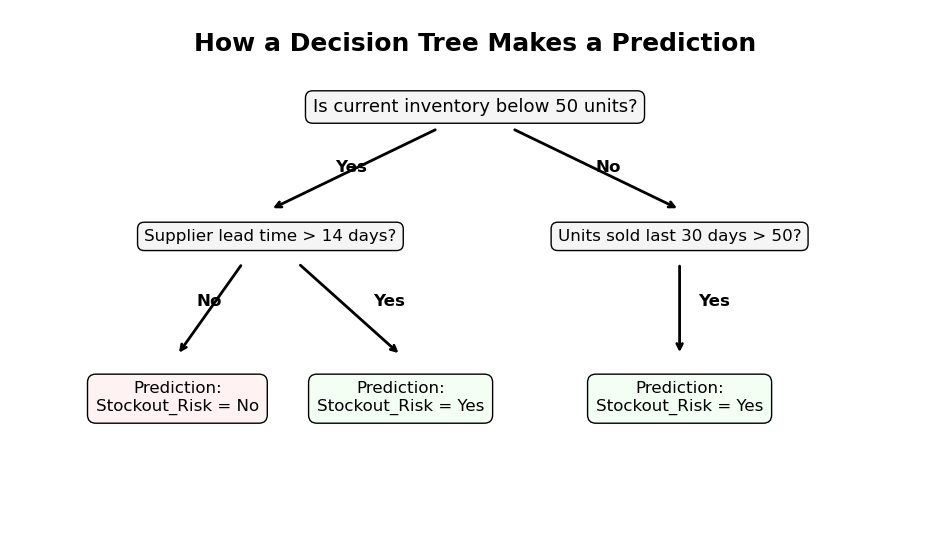

In [68]:
import matplotlib.pyplot as plt

# Create a figure and axis
fig, ax = plt.subplots(figsize=(12, 7))

# Set the x-axis range
ax.set_xlim(0, 1)

# Set the y-axis range
ax.set_ylim(0, 1)

# Turn off the axis
ax.axis("off")

# Add the title
ax.text(
    0.5, 0.96,
    "How a Decision Tree Makes a Prediction",
    ha="center",
    va="top",
    fontsize=18,
    fontweight="bold"
)

# Add the first question box
ax.text(
    0.5, 0.82,
    "Is current inventory below 50 units?",
    ha="center",
    va="center",
    fontsize=13,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#f5f5f5", edgecolor="black")
)

# Add the left second question box
ax.text(
    0.28, 0.58,
    "Supplier lead time > 14 days?",
    ha="center",
    va="center",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#f5f5f5", edgecolor="black")
)

# Add the right second question box
ax.text(
    0.72, 0.58,
    "Units sold last 30 days > 50?",
    ha="center",
    va="center",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#f5f5f5", edgecolor="black")
)

# Add the left prediction box
ax.text(
    0.18, 0.28,
    "Prediction:\nStockout_Risk = No",
    ha="center",
    va="center",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#fff2f2", edgecolor="black")
)

# Add the middle prediction box
ax.text(
    0.42, 0.28,
    "Prediction:\nStockout_Risk = Yes",
    ha="center",
    va="center",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#f2fff2", edgecolor="black")
)

# Add the right prediction box
ax.text(
    0.72, 0.28,
    "Prediction:\nStockout_Risk = Yes",
    ha="center",
    va="center",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#f2fff2", edgecolor="black")
)

# Draw arrow from first question to left second question
ax.annotate(
    "",
    xy=(0.28, 0.63),
    xytext=(0.46, 0.78),
    arrowprops=dict(arrowstyle="->", linewidth=2)
)

# Draw arrow from first question to right second question
ax.annotate(
    "",
    xy=(0.72, 0.63),
    xytext=(0.54, 0.78),
    arrowprops=dict(arrowstyle="->", linewidth=2)
)

# Add branch label for Yes (low inventory)
ax.text(0.35, 0.70, "Yes", fontsize=12, fontweight="bold")

# Add branch label for No (inventory not low)
ax.text(0.63, 0.70, "No", fontsize=12, fontweight="bold")

# Draw arrow from left second question to left prediction
ax.annotate(
    "",
    xy=(0.18, 0.36),
    xytext=(0.25, 0.53),
    arrowprops=dict(arrowstyle="->", linewidth=2)
)

# Draw arrow from left second question to middle prediction
ax.annotate(
    "",
    xy=(0.42, 0.36),
    xytext=(0.31, 0.53),
    arrowprops=dict(arrowstyle="->", linewidth=2)
)

# Draw arrow from right second question to right prediction
ax.annotate(
    "",
    xy=(0.72, 0.36),
    xytext=(0.72, 0.53),
    arrowprops=dict(arrowstyle="->", linewidth=2)
)

# Add branch label for No from supplier lead time
ax.text(0.20, 0.45, "No", fontsize=12, fontweight="bold")

# Add branch label for Yes from supplier lead time
ax.text(0.39, 0.45, "Yes", fontsize=12, fontweight="bold")

# Add branch label for Yes from units sold
ax.text(0.74, 0.45, "Yes", fontsize=12, fontweight="bold")

# Display the figure
plt.show()

In [69]:
# Import DecisionTreeClassifier from scikit-learn
from sklearn.tree import DecisionTreeClassifier

In [70]:
# Create a Decision Tree classification model
decision_tree_model = DecisionTreeClassifier(
    
    # Limit the depth of the tree to make it easier to understand
    max_depth=4,
    
    # Use a fixed random state to make the result reproducible
    random_state=42
)

# Print a message to confirm that the model has been created
print("Decision Tree model has been created.")

Decision Tree model has been created.


In [71]:
# Train the Decision Tree model using the preprocessed training data
decision_tree_model.fit(X_train_processed_df, y_train)

# Print a message to confirm that the model has been trained
print("Decision Tree model has been trained successfully.")

Decision Tree model has been trained successfully.


In [72]:
print("Decision Tree Model Information")

# Print a separator line
print("-" * 50)

# Display the trained model
print(decision_tree_model)

Decision Tree Model Information
--------------------------------------------------
DecisionTreeClassifier(max_depth=4, random_state=42)


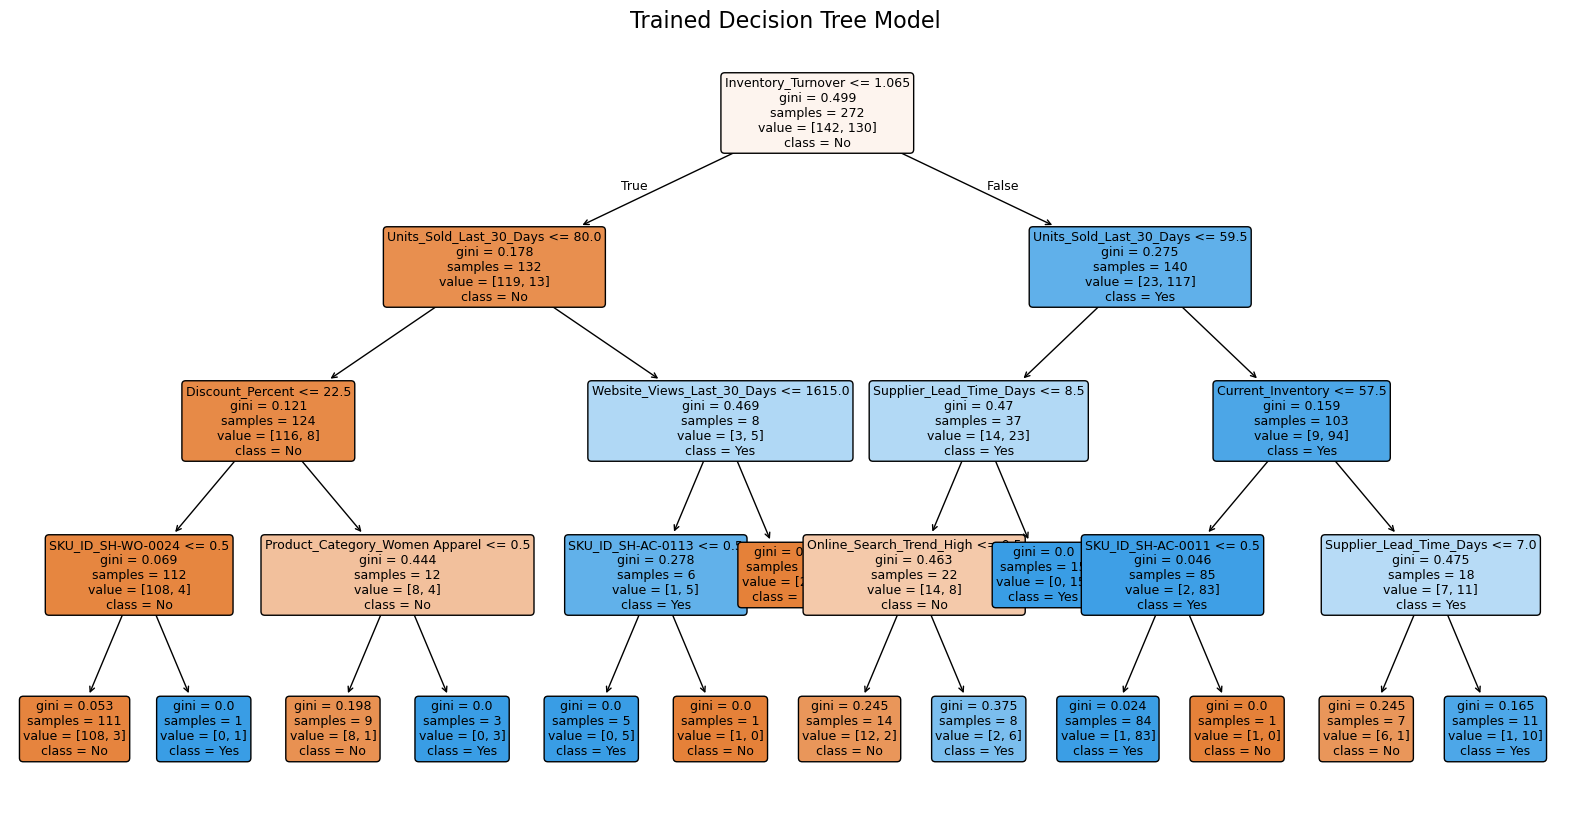

In [73]:
import matplotlib.pyplot as plt

# Import plot_tree to visualize the Decision Tree
from sklearn.tree import plot_tree

# Create a large figure for the tree visualization
plt.figure(figsize=(20, 10))

# Plot the trained Decision Tree
plot_tree(
    
    # Use the trained Decision Tree model
    decision_tree_model,
    
    # Use feature names from the processed training data
    feature_names=X_train_processed_df.columns,
    
    # Show class names from the target variable
    class_names=decision_tree_model.classes_,
    
    # Fill the tree boxes to make the classes easier to distinguish
    filled=True,
    
    # Round the corners of the boxes
    rounded=True,
    
    # Set the font size
    fontsize=9
)

# Add a title to the figure
plt.title("Trained Decision Tree Model", fontsize=16)

# Display the figure
plt.show()

In [74]:
# Get the depth of the trained Decision Tree
tree_depth = decision_tree_model.get_depth()

# Get the number of leaf nodes in the trained Decision Tree
tree_leaves = decision_tree_model.get_n_leaves()

# Print the depth of the tree
print("Decision Tree depth:", tree_depth)

# Print the number of leaf nodes
print("Number of leaf nodes:", tree_leaves)

Decision Tree depth: 4
Number of leaf nodes: 14


In [75]:
# Use the trained Decision Tree model to predict the target values for the testing data
y_pred_dt = decision_tree_model.predict(X_test_processed_df)

# Print a message to confirm that predictions have been created
print("Decision Tree predictions have been created successfully.")

Decision Tree predictions have been created successfully.


In [76]:
# Create a DataFrame to compare actual and predicted values
dt_results = pd.DataFrame({
    
    # Store the actual values from the testing set
    "Actual": y_test.values,
    
    # Store the predicted values from the Decision Tree model
    "Predicted": y_pred_dt
})

# Print a title for the output
print("Actual vs Predicted Values")

# Print a separator line
print("-" * 50)

# Display the first ten actual and predicted values
display(dt_results.head(10))

Actual vs Predicted Values
--------------------------------------------------


,Actual,Predicted
0,Yes,No
1,Yes,No
2,No,No
3,No,No
4,No,No
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,No,No
9,Yes,Yes


In [77]:
# Import accuracy_score to calculate model accuracy
from sklearn.metrics import accuracy_score

# Calculate the accuracy of the Decision Tree model on the testing data
dt_test_accuracy = accuracy_score(y_test, y_pred_dt)

# Print the Decision Tree testing accuracy
print("Decision Tree Test Accuracy:")

# Display the accuracy value
print(dt_test_accuracy)


Decision Tree Test Accuracy:
0.8235294117647058


In [78]:
# Predict the target values for the training data
y_train_pred_dt = decision_tree_model.predict(X_train_processed_df)

# Calculate the accuracy of the model on the training data
dt_train_accuracy = accuracy_score(y_train, y_train_pred_dt)

# Calculate the accuracy of the model on the testing data
dt_test_accuracy = accuracy_score(y_test, y_pred_dt)

# Print the training accuracy
print("Decision Tree Training Accuracy:", dt_train_accuracy)

# Print the testing accuracy
print("Decision Tree Testing Accuracy:", dt_test_accuracy)

Decision Tree Training Accuracy: 0.9595588235294118
Decision Tree Testing Accuracy: 0.8235294117647058


In [79]:
# Create a small table to compare training and testing accuracy
dt_accuracy_table = pd.DataFrame({
    
    # Store model evaluation type
    "Evaluation Set": ["Training Set", "Testing Set"],
    
    # Store accuracy values
    "Accuracy": [dt_train_accuracy, dt_test_accuracy]
})

# Display the accuracy comparison table
display(dt_accuracy_table)

,Evaluation Set,Accuracy
0,Training Set,0.959559
1,Testing Set,0.823529


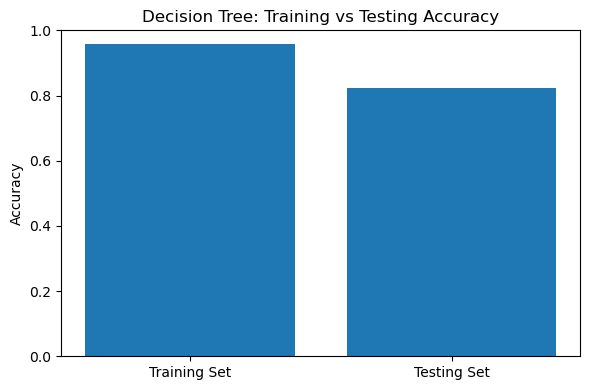

In [80]:
# Import matplotlib for creating charts
import matplotlib.pyplot as plt

# Create a figure for the accuracy comparison chart
plt.figure(figsize=(6, 4))

# Create a bar chart for training and testing accuracy
plt.bar(dt_accuracy_table["Evaluation Set"], dt_accuracy_table["Accuracy"])

# Add a title to the chart
plt.title("Decision Tree: Training vs Testing Accuracy")

# Add a label to the y-axis
plt.ylabel("Accuracy")

# Set the y-axis range from 0 to 1
plt.ylim(0, 1)

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

In [81]:
actual_counts = y_test.value_counts()

# Count predicted class values from the Decision Tree model
predicted_counts = pd.Series(y_pred_dt).value_counts()

# Create a comparison table for actual and predicted class counts
class_count_comparison = pd.DataFrame({
    
    # Store actual class counts
    "Actual": actual_counts,
    
    # Store predicted class counts
    "Predicted": predicted_counts
})

# Fill any missing values with zero
class_count_comparison = class_count_comparison.fillna(0)

# Display the comparison table
display(class_count_comparison)

,Actual,Predicted
No,35,41
Yes,33,27


<Figure size 700x400 with 0 Axes>

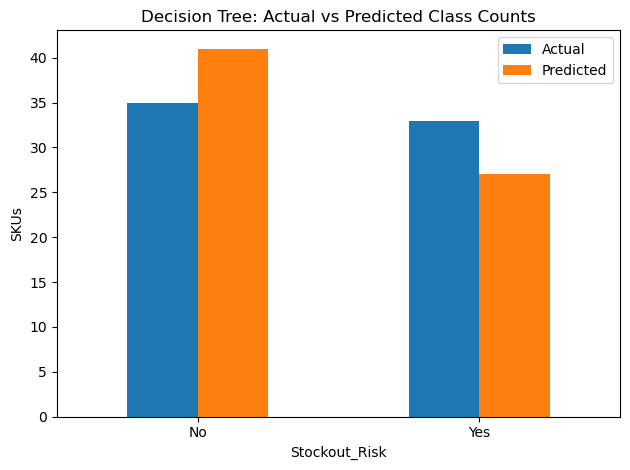

In [83]:
# Create a figure for actual vs predicted class counts
plt.figure(figsize=(7, 4))

# Create a bar chart for actual and predicted class counts
class_count_comparison.plot(kind="bar")

# Add a title to the chart
plt.title("Decision Tree: Actual vs Predicted Class Counts")

# Add a label to the x-axis
plt.xlabel("Stockout_Risk")

# Add a label to the y-axis
plt.ylabel("SKUs")

# Rotate x-axis labels
plt.xticks(rotation=0)

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

In [84]:
# Import confusion_matrix to calculate the confusion matrix
from sklearn.metrics import confusion_matrix

# Import ConfusionMatrixDisplay to visualize the confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Import matplotlib for creating the figure
import matplotlib.pyplot as plt

In [85]:
# Define the class labels in a fixed order
class_labels = ["No", "Yes"]

# Calculate the confusion matrix for the Decision Tree model
cm_dt = confusion_matrix(y_test, y_pred_dt, labels=class_labels)

# Print a title for the output
print("Decision Tree Confusion Matrix")

# Print a separator line
print("-" * 50)

# Display the confusion matrix values
print(cm_dt)

Decision Tree Confusion Matrix
--------------------------------------------------
[[32  3]
 [ 9 24]]


In [86]:
cm_dt_table = pd.DataFrame(
    
    # Use the confusion matrix values
    cm_dt,
    
    # Set row labels as actual classes
    index=["Actual No", "Actual Yes"],
    
    # Set column labels as predicted classes
    columns=["Predicted No", "Predicted Yes"]
)

# Display the confusion matrix table
display(cm_dt_table)

,Predicted No,Predicted Yes
Actual No,32,3
Actual Yes,9,24


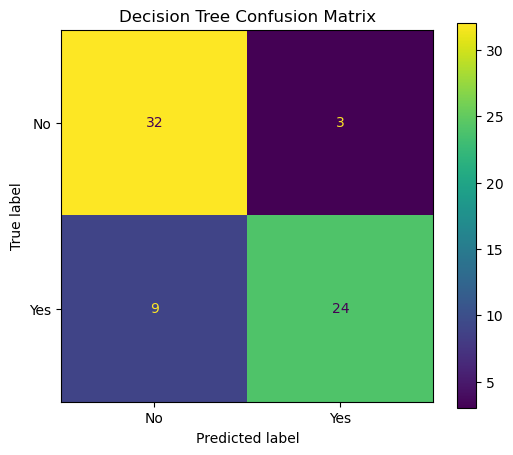

In [87]:
fig, ax = plt.subplots(figsize=(6, 5))

# Create a confusion matrix display object
disp = ConfusionMatrixDisplay(
    
    # Use the Decision Tree confusion matrix
    confusion_matrix=cm_dt,
    
    # Use class labels for display
    display_labels=class_labels
)

# Plot the confusion matrix
disp.plot(ax=ax, values_format="d")

# Add a title to the figure
plt.title("Decision Tree Confusion Matrix")

# Display the figure
plt.show()

In [88]:
tn, fp, fn, tp = cm_dt.ravel()

# Print True Negative value
print("True Negative:", tn)

# Print False Positive value
print("False Positive:", fp)

# Print False Negative value
print("False Negative:", fn)

# Print True Positive value
print("True Positive:", tp)

True Negative: 32
False Positive: 3
False Negative: 9
True Positive: 24


In [89]:
# Create a table to explain each part of the confusion matrix
confusion_explanation = pd.DataFrame({
    
    # Name of each confusion matrix component
    "Component": [
        "True Negative",
        "False Positive",
        "False Negative",
        "True Positive"
    ],
    
    # Meaning of each component in this business problem
    "Meaning": [
        "Product was not at stockout risk, and the model correctly predicted No",
        "Product was not at stockout risk, but the model incorrectly predicted Yes",
        "Product was at stockout risk, but the model incorrectly predicted No",
        "Product was at stockout risk, and the model correctly predicted Yes"
    ],
    
    # Store the calculated values
    "Value": [tn, fp, fn, tp]
})

# Display the explanation table
display(confusion_explanation)

,Component,Meaning,Value
0,True Negative,"Product was not at stockout risk, and the mode...",32
1,False Positive,"Product was not at stockout risk, but the mode...",3
2,False Negative,"Product was at stockout risk, but the model in...",9
3,True Positive,"Product was at stockout risk, and the model co...",24


In [90]:
from sklearn.metrics import accuracy_score

# Import precision_score to calculate precision
from sklearn.metrics import precision_score

# Import recall_score to calculate recall
from sklearn.metrics import recall_score

# Import f1_score to calculate the F1-score
from sklearn.metrics import f1_score

# Import classification_report to show a full performance summary
from sklearn.metrics import classification_report

In [91]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)

# Print the accuracy score
print("Decision Tree Accuracy:")

# Display the accuracy value
print(dt_accuracy)

Decision Tree Accuracy:
0.8235294117647058


In [92]:
dt_precision = precision_score(y_test, y_pred_dt, pos_label="Yes", zero_division=0)

# Print the precision score
print("Decision Tree Precision:")

# Display the precision value
print(dt_precision)

Decision Tree Precision:
0.8888888888888888


In [93]:
dt_recall = recall_score(y_test, y_pred_dt, pos_label="Yes", zero_division=0)

# Print the recall score
print("Decision Tree Recall:")

# Display the recall value
print(dt_recall)

Decision Tree Recall:
0.7272727272727273


In [94]:
dt_f1 = f1_score(y_test, y_pred_dt, pos_label="Yes", zero_division=0)

# Print the F1-score
print("Decision Tree F1-Score:")

# Display the F1-score value
print(dt_f1)

Decision Tree F1-Score:
0.8


In [95]:
dt_metrics_table = pd.DataFrame({
    
    # Store the metric names
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    
    # Store the metric values
    "Score": [dt_accuracy, dt_precision, dt_recall, dt_f1]
})

# Display the metrics summary table
display(dt_metrics_table)

,Metric,Score
0,Accuracy,0.823529
1,Precision,0.888889
2,Recall,0.727273
3,F1-Score,0.800000


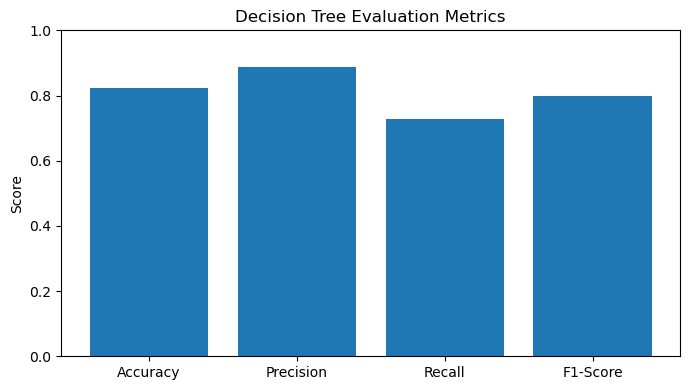

In [96]:
# Import matplotlib for creating charts
import matplotlib.pyplot as plt

# Create a figure for the evaluation metrics chart
plt.figure(figsize=(7, 4))

# Create a bar chart for the metrics
plt.bar(dt_metrics_table["Metric"], dt_metrics_table["Score"])

# Add a title to the chart
plt.title("Decision Tree Evaluation Metrics")

# Add a label to the y-axis
plt.ylabel("Score")

# Set the y-axis range from 0 to 1
plt.ylim(0, 1)

# Adjust the layout so labels do not overlap
plt.tight_layout()

# Display the chart
plt.show()

In [97]:
# Print a title for the classification report
print("Decision Tree Classification Report")

# Print a separator line
print("-" * 50)

# Display the classification report for both classes
print(classification_report(y_test, y_pred_dt, zero_division=0))

Decision Tree Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

          No       0.78      0.91      0.84        35
         Yes       0.89      0.73      0.80        33

    accuracy                           0.82        68
   macro avg       0.83      0.82      0.82        68
weighted avg       0.83      0.82      0.82        68



In [98]:
from sklearn.tree import DecisionTreeClassifier

# Create a Decision Tree model without limiting max_depth
overfit_tree_model = DecisionTreeClassifier(
    
    # Allow the tree to grow as much as possible
    max_depth=None,
    
    # Use a fixed random state to make the result reproducible
    random_state=42
)

# Train the overfitted Decision Tree model using the processed training data
overfit_tree_model.fit(X_train_processed_df, y_train)

# Print a message to confirm that the model has been trained
print("Overfitted Decision Tree model has been trained.")

Overfitted Decision Tree model has been trained.


In [99]:
# Predict the target values for the training data using the overfitted tree
y_train_pred_overfit = overfit_tree_model.predict(X_train_processed_df)

# Predict the target values for the testing data using the overfitted tree
y_test_pred_overfit = overfit_tree_model.predict(X_test_processed_df)

# Calculate training accuracy for the overfitted tree
overfit_train_accuracy = accuracy_score(y_train, y_train_pred_overfit)

# Calculate testing accuracy for the overfitted tree
overfit_test_accuracy = accuracy_score(y_test, y_test_pred_overfit)

# Print the training accuracy
print("Overfitted Tree Training Accuracy:", overfit_train_accuracy)

# Print the testing accuracy
print("Overfitted Tree Testing Accuracy:", overfit_test_accuracy)

Overfitted Tree Training Accuracy: 1.0
Overfitted Tree Testing Accuracy: 0.8235294117647058


In [100]:
# Predict the target values for the training data using the controlled Decision Tree
y_train_pred_controlled = decision_tree_model.predict(X_train_processed_df)

# Predict the target values for the testing data using the controlled Decision Tree
y_test_pred_controlled = decision_tree_model.predict(X_test_processed_df)

# Calculate training accuracy for the controlled Decision Tree
controlled_train_accuracy = accuracy_score(y_train, y_train_pred_controlled)

# Calculate testing accuracy for the controlled Decision Tree
controlled_test_accuracy = accuracy_score(y_test, y_test_pred_controlled)

# Create a comparison table for both models
overfitting_comparison = pd.DataFrame({
    
    # Store the model names
    "Model": ["Controlled Decision Tree", "Overfitted Decision Tree"],
    
    # Store the training accuracy values
    "Training Accuracy": [controlled_train_accuracy, overfit_train_accuracy],
    
    # Store the testing accuracy values
    "Testing Accuracy": [controlled_test_accuracy, overfit_test_accuracy]
})

# Display the comparison table
display(overfitting_comparison)

,Model,Training Accuracy,Testing Accuracy
0,Controlled Decision Tree,0.959559,0.823529
1,Overfitted Decision Tree,1.000000,0.823529


<Figure size 800x500 with 0 Axes>

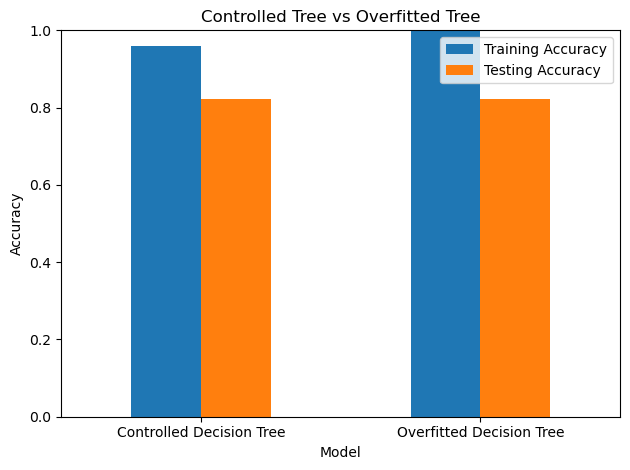

In [101]:
# Import matplotlib for creating charts
import matplotlib.pyplot as plt

# Set the model column as the index for better plotting
overfitting_comparison_plot = overfitting_comparison.set_index("Model")

# Create a figure for the comparison chart
plt.figure(figsize=(8, 5))

# Create a bar chart for training and testing accuracy
overfitting_comparison_plot.plot(kind="bar")

# Add a title to the chart
plt.title("Controlled Tree vs Overfitted Tree")

# Add a label to the y-axis
plt.ylabel("Accuracy")

# Set the y-axis range from 0 to 1
plt.ylim(0, 1)

# Rotate x-axis labels for better readability
plt.xticks(rotation=0)

# Adjust layout to avoid overlap
plt.tight_layout()

# Display the chart
plt.show()

In [102]:
# Get the depth of the controlled Decision Tree
controlled_tree_depth = decision_tree_model.get_depth()

# Get the number of leaf nodes in the controlled Decision Tree
controlled_tree_leaves = decision_tree_model.get_n_leaves()

# Get the depth of the overfitted Decision Tree
overfit_tree_depth = overfit_tree_model.get_depth()

# Get the number of leaf nodes in the overfitted Decision Tree
overfit_tree_leaves = overfit_tree_model.get_n_leaves()

# Create a table to compare tree complexity
tree_complexity_table = pd.DataFrame({
    
    # Store the model names
    "Model": ["Controlled Decision Tree", "Overfitted Decision Tree"],
    
    # Store tree depth values
    "Tree Depth": [controlled_tree_depth, overfit_tree_depth],
    
    # Store number of leaf nodes
    "Number of Leaves": [controlled_tree_leaves, overfit_tree_leaves]
})

# Display the tree complexity table
display(tree_complexity_table)

,Model,Tree Depth,Number of Leaves
0,Controlled Decision Tree,4,14
1,Overfitted Decision Tree,7,24


In [ ]:
#Write a short interpretation based on your model results and the business plan.

#How well did the Decision Tree model perform?
#The model predicts a testing accuracy of 82%, with a precision of 88%, recall of 72%
and an F1-score of 80% for predicting stockout risk. Out of 33 actual high-risk products
in the test set, it correctly identified 24. 

#Is there a large difference between training accuracy and testing accuracy?
# The data has a large difference between training accuracy and testing accuracy.
  Training accuracy was 95%, and testing accuracy was 82%, which has a gap of nearly
  13% points.

#Does the model show signs of overfitting? Why or why not?
# The controlled tree shows moderate overfitting, given the 13% accuracy gap.
  It reaches 100% training accuracy but only 82% on the test set. The model is learning
  Some patterns specific to the training data don't hold perfectly for the new product. 

#Which evaluation metric is most important for this business problem?
# The biggest risk for StyleHub is failing to catch up on a product that is about to be out of stock. 
  High recall ensures the model catches as many stockout risks as possible.
      
#What do false positives mean in this business context?
# A false positive means that the model predicted a product was at to stockout risk
  but it actually has enough inventory. The model predicts 3 false positive that mean
 a very low risk.

#What do false negatives mean in this business context?
# A false negative means that a product was at stouckout risk, but the model predicted
 it was safe, and the product actually sold out and is out of inventory. 

# Which features were most important in the Decision Tree model?
# The most important features in the decision model were inventory turnover, supplies lead time,
     current inventory, units sold last 30 days, online search, gross margin, discount% and 
     product category.

#How can these important features help the business make better decisions?
# Inventory turnover is the dominant feature, which means products that sell through their stock
 quickly are at high risk. StyleHub should set some alerts to restock for the high turnout rate.
The supply lead time is another important feature, which means the high turnover rate
products need a quick supply chain and supply in less time.

#What is one possible limitation or bias in the model or dataset?
# The dataset contains 340 inventory records, which is relatively not a big dataset.
Because of that, the dataset might have a bias of a small size. 

#Why should human judgment still be used when making business decisions based on model results?
#As the data accuracy was 82%, the model still misses a few risks. They should analyze 
    by predicting the results, but still rely on human judgment. Machine learning can help to
    improve the predictions and results byt can not be accurate without human judgment. 